In [4]:
import os
import oracledb
from dotenv import load_dotenv
import pandas as pd

load_dotenv()

def create_cursor():
    connection = oracledb.connect(
        user=os.getenv("ORACLE_USER"),
        password=os.getenv("ORACLE_PASSWORD"),
        dsn=oracledb.makedsn("localhost", 1522, service_name="stu"),
    )
    cursor = connection.cursor()
    print("Connected to Oracle")
    return connection, cursor

# RQ2: Are election years associated with significantly higher YouTube engagement on politically aligned channels compared to non-election years?

In [5]:
connection, cursor = create_cursor()
try: 
    rq2_query = """
SELECT
a.election_year,
a.youtube_use,
a.lib_con_scale,
COUNT(*) AS respondent_count,
ROUND(AVG(a.democrat_thermometer), 2) AS avg_dem_thermometer,
ROUND(AVG(a.republican_thermometer), 2) AS avg_rep_thermometer,
ROUND(AVG(a.democrat_thermometer) - AVG(a.republican_thermometer), 2) AS partisan_lean
FROM anes_2020 a
WHERE a.youtube_use IS NOT NULL
AND a.lib_con_scale NOT IN ('DK', 'Refused')
AND a.lib_con_scale IS NOT NULL
GROUP BY a.election_year, a.youtube_use, a.lib_con_scale

UNION ALL

SELECT
a.election_year,
a.youtube_use,
a.lib_con_scale,
COUNT(*),
ROUND(AVG(a.democrat_thermometer), 2),
ROUND(AVG(a.republican_thermometer), 2),
ROUND(AVG(a.democrat_thermometer) - AVG(a.republican_thermometer), 2)
FROM anes_2024 a
WHERE a.youtube_use IS NOT NULL
AND a.lib_con_scale NOT IN ('DK', 'Refused')
AND a.lib_con_scale IS NOT NULL
GROUP BY a.election_year, a.youtube_use, a.lib_con_scale

ORDER BY election_year, youtube_use, lib_con_scale
"""

    cursor.execute(rq2_query)
    results = cursor.fetchall()
    rq2_df = pd.DataFrame(results, columns=[d[0] for d in cursor.description])
    display(rq2_df.head())
except Exception as e:
    print("Error executing query", e)

cursor.close()
connection.close()

Connected to Oracle


,ELECTION_YEAR,YOUTUBE_USE,LIB_CON_SCALE,RESPONDENT_COUNT,AVG_DEM_THERMOMETER,AVG_REP_THERMOMETER,PARTISAN_LEAN
0,2020,No,Conservative,13,26.77,73.38,-46.62
1,2020,No,Extremely Liberal,5,47.00,20.00,27.00
2,2020,No,Extremely conservative,5,18.00,91.00,-73.00
3,2020,No,Liberal,10,85.50,5.00,80.50
4,2020,No,Moderate,15,65.33,35.33,30.00


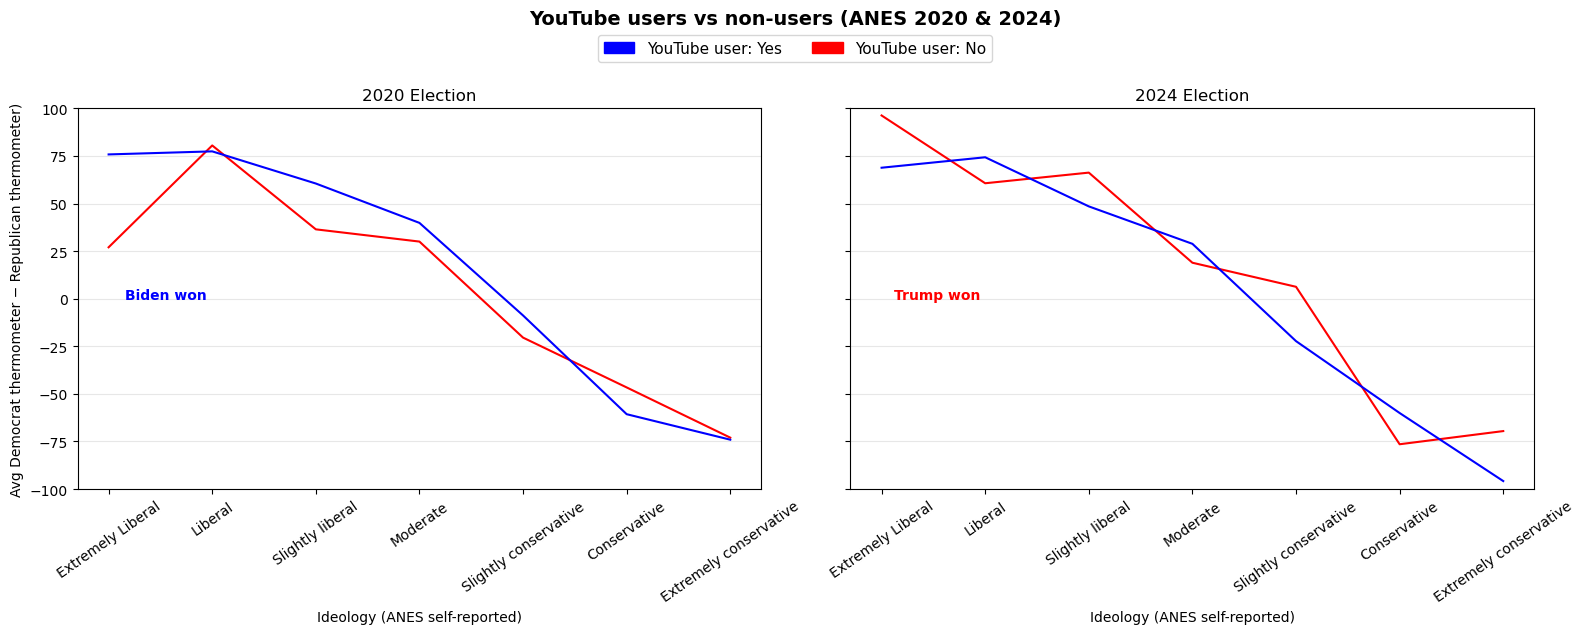

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ideology_order = ['Extremely Liberal', 'Liberal', 'Slightly liberal','Moderate', 'Slightly conservative', 'Conservative', 'Extremely conservative']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
years = [2020, 2024]
colors = {'Yes': 'blue', 'No': 'red'}

for ax, year in zip(axes, years):
    df_year = rq2_df[rq2_df['ELECTION_YEAR'] == year].copy()

    for youtube_use, group in df_year.groupby('YOUTUBE_USE'):
        group = group[group['LIB_CON_SCALE'].isin(ideology_order)].copy()
        group['ideology_rank'] = group['LIB_CON_SCALE'].map(
            {v: i for i, v in enumerate(ideology_order)}
        )
        group = group.sort_values('ideology_rank')

        ax.plot(
            group['LIB_CON_SCALE'],
            group['PARTISAN_LEAN'],
            label=f'YouTube user: {youtube_use}',
            color=colors[youtube_use]
        )

    winner = 'Biden won' if year == 2020 else 'Trump won'
    winner_color = 'blue' if year == 2020 else 'red'
    ax.annotate(winner, xy=(0.95, 0.05), ha='right', color=winner_color, fontweight='bold')
    ax.set_title(f'{year} Election')
    ax.set_xlabel('Ideology (ANES self-reported)')
    ax.tick_params(axis='x', rotation=35)
    ax.set_ylim(-100, 100)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Avg Democrat thermometer − Republican thermometer)')
# legend
blue_patch = mpatches.Patch(color='blue', label='YouTube user: Yes')
orange_patch = mpatches.Patch(color='red', label='YouTube user: No')
fig.legend(handles=[blue_patch, orange_patch], loc='upper center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.02))

fig.suptitle('YouTube users vs non-users (ANES 2020 & 2024)', fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('rq2_partisan_lean.png')
plt.show()